# Startup Investment Outcome — Feature Selection & Modeling

**Input:** `data/train_resampled.csv`, `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Select the most informative features using statistical tests and model-based importance methods, then train and compare multiple classifiers with regularization, selecting the best model for final evaluation on the test set.  
**Note:** All feature selection is fit on the **training set only**. Validation and test sets are transformed, never used to fit selectors.

This notebook follows the same structure as `04_Imbalanced_Data.ipynb`.  
Each section ends with a **→ Modeling Decision** box.

**Pipeline position:**
```
01_EDA → 02_... → 03_Preprocessing → 04_Imbalanced_Data → [05_Feature_Selection_Modeling] ← you are here
```

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Feature selection
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2,
    SelectFromModel, SequentialFeatureSelector
)

# Models
from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

# Permutation importance
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

STATUS_MAP   = {0: 'closed', 1: 'operating', 2: 'acquired'}
STATUS_NAMES = ['closed', 'operating', 'acquired']
COLORS       = ['#FF5722', '#2196F3', '#4CAF50']
RANDOM_STATE = 42

## 1. Load Data

The processed CSVs come from `03_Preprocessing.ipynb`. Notebook `04_Imbalanced_Data.ipynb` produces
five training files (one per resampling strategy). We need to pick **one** for Part A feature selection:

| File | Used for |
|------|----------|
| `train_resampled_smote.csv` | **Part A — feature selection** (default; change `FEATURE_SELECTION_FILE` if needed) |
| `train_resampled_ros.csv` | Part B — model training |
| `train_resampled_rus.csv` | Part B — model training |
| `train_resampled_smote.csv` | Part B — model training |
| `train_resampled_smotetomek.csv` | Part B — model training |

Using SMOTE for feature selection is a reasonable default — it produces a balanced,
synthesised dataset without simply duplicating rows (ROS) or discarding data (RUS).
If you want to use a different file, change `FEATURE_SELECTION_FILE` in the cell below.

**Raw funding columns** (`funding_total_usd`, `seed`, `venture`, …) are dropped here
because `FundingLogTransformer` in `03_Preprocessing` creates `log_<col>` versions
but does not remove the originals from the CSV.


In [2]:
# Feature selection needs one representative training set for fitting selectors.
# We use SMOTE as the default — it synthesises new minority samples rather than
# simply duplicating (ROS) or discarding (RUS), giving a balanced but realistic
# feature space for the selection methods to work on.
# All four resampling files are loaded in Part B (Section 11) for model training.
FEATURE_SELECTION_FILE = 'data/train_resampled_smote.csv'

train = pd.read_csv(FEATURE_SELECTION_FILE)
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

# ── Drop columns not used for modeling ────────────────────────────────────
# geo_cluster: non-numeric cluster label (kept for EDA reference in 03_Preprocessing)
# Raw funding columns: 03_Preprocessing applies log1p via FundingLogTransformer,
# producing log_<col> versions. The originals are left in the CSV but must NOT
# be fed to the model — using both raw + log would introduce redundancy and
# let the model bypass the intended transformation.
RAW_FUNDING_COLS = [
    'funding_total_usd', 'seed', 'venture', 'angel', 'grant',
    'private_equity', 'debt_financing', 'equity_crowdfunding',
    'convertible_note', 'undisclosed', 'product_crowdfunding',
    'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
]

DROP_COLS = ['status_code', 'geo_cluster'] + RAW_FUNDING_COLS

def prepare_X(df):
    cols_to_drop = [c for c in DROP_COLS if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train = prepare_X(train)
y_train = train['status_code']

X_val   = prepare_X(val)
y_val   = val['status_code']

X_test  = prepare_X(test)
y_test  = test['status_code']

# Verify log_ columns are present and raw columns are gone
log_funding_cols  = [c for c in X_train.columns if c.startswith('log_')]
raw_still_present = [c for c in RAW_FUNDING_COLS if c in X_train.columns]
print(f"Feature selection train file : {FEATURE_SELECTION_FILE}")
print(f"Train shape : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nLog-transformed funding features ({len(log_funding_cols)}): {log_funding_cols}")
print(f"Raw funding cols remaining (should be 0): {raw_still_present}")
print(f"\nAll features ({len(X_train.columns)}):")
print(list(X_train.columns))
print(f"\nClass distribution (train):")
for k, cnt in y_train.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")


Feature selection train file : data/train_resampled_smote.csv
Train shape : (72294, 30)  |  Val: (5971, 30)  |  Test: (5971, 30)

Log-transformed funding features (14): ['log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market']
Raw funding cols remaining (should be 0): []

All features (30):
['funding_rounds', 'round_A', 'round_B', 'round_C', 'founded_year', 'founded_month', 'founded_quarter', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'has_round_A', 'has_round_B', 'has_round_C', 'round_D_plus', 'days_to_first_funding',

## 2. Evaluation Helper

Reuse the same helper pattern from `04_Imbalanced_Data.ipynb` — consistent metrics across all notebooks.

In [3]:
def classification_metrics(y_true, y_pred, model_name=''):
    """Return a metrics dict for multiclass classification."""
    per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])
    return {
        'Model':        model_name,
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Macro F1':     f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':  f1_score(y_true, y_pred, average='weighted'),
        'F1 closed':    per_class[0],
        'F1 operating': per_class[1],
        'F1 acquired':  per_class[2],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    if ax is None:
        plt.tight_layout()
        plt.show()

---
# Part A — Feature Selection

We apply three complementary families of feature selection and aggregate their votes.

| Family | Methods |
|--------|---------|
| **Statistical (filter)** | ANOVA F-test, Chi-squared |
| **Model importance (wrapper)** | Random Forest, Gradient Boosting, Lasso, Ridge, Linear SVM |
| **Sequential wrapper** | Forward Selection (Random Forest base) |
| **Post-hoc** | Permutation Importance |

## 3. Statistical Feature Selection (Filter Methods)

Filter methods rank features **independently of any model**, using statistical tests to measure the relationship between each feature and the target.

### 3.1 ANOVA F-test (`f_classif`)

**ANOVA (Analysis of Variance)** tests whether the group means (per class) of a feature differ significantly.  
- High F-value → large variance *between* classes relative to variance *within* classes → feature discriminates well.  
- Low p-value → we can reject the null hypothesis that all class means are equal.

In [4]:
f_values, p_values = f_classif(X_train, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F-Value': f_values,
    'P-Value': p_values
}).sort_values('F-Value', ascending=False).reset_index(drop=True)

print("ANOVA F-test results (sorted by F-value):")
display(anova_df.round(4))

ANOVA F-test results (sorted by F-value):


,Feature,F-Value,P-Value
0,log_funding_total_usd,5126.3177,0.0000
1,market_enc_acquired,3984.0593,0.0000
2,market_enc_closed,3763.2104,0.0000
3,log_venture,3122.8072,0.0000
4,country_code_enc_acquired,1811.0586,0.0000
5,has_round_B,1676.2210,0.0000
6,funding_rounds,1543.4428,0.0000
7,has_round_C,1474.6182,0.0000
8,founded_year,1333.4072,0.0000
9,has_round_A,970.2390,0.0000


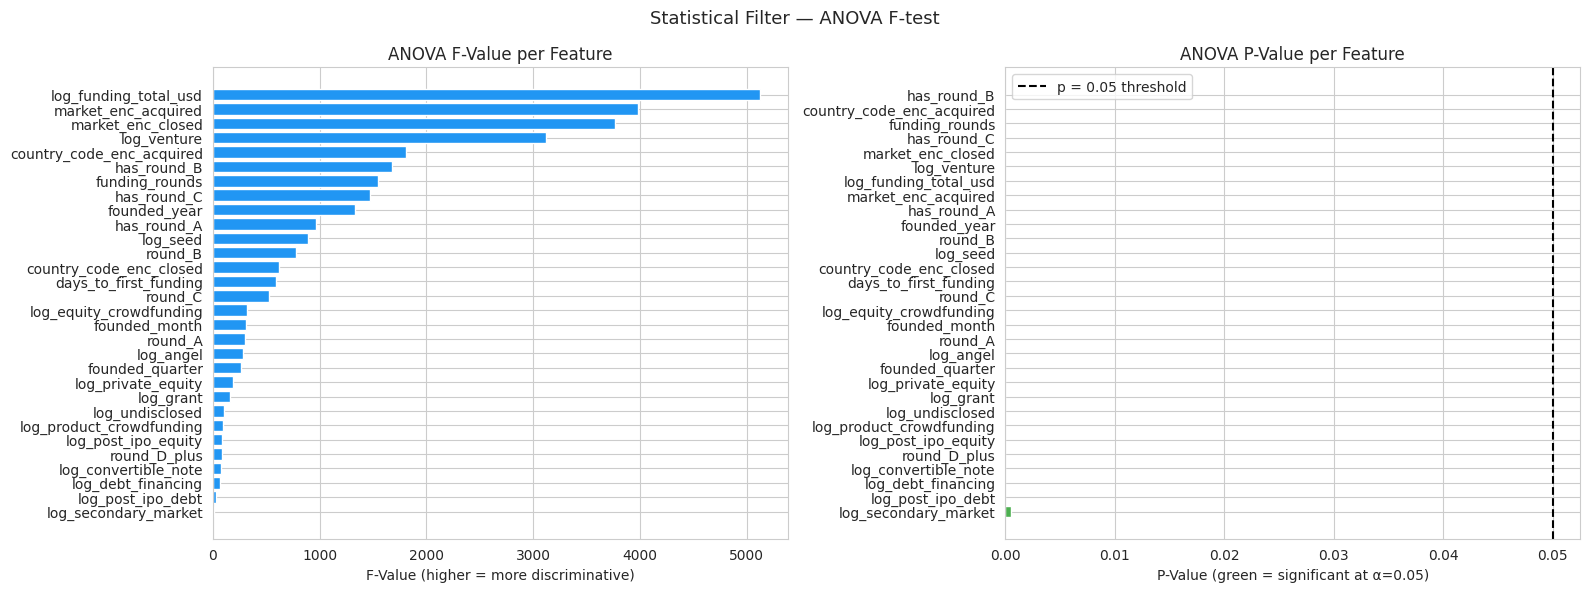


Features significant at α=0.05 (30): ['log_funding_total_usd', 'market_enc_acquired', 'market_enc_closed', 'log_venture', 'country_code_enc_acquired', 'has_round_B', 'funding_rounds', 'has_round_C', 'founded_year', 'has_round_A', 'log_seed', 'round_B', 'country_code_enc_closed', 'days_to_first_funding', 'round_C', 'log_equity_crowdfunding', 'founded_month', 'round_A', 'log_angel', 'founded_quarter', 'log_private_equity', 'log_grant', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'round_D_plus', 'log_convertible_note', 'log_debt_financing', 'log_post_ipo_debt', 'log_secondary_market']


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-values bar chart
sorted_f = anova_df.sort_values('F-Value', ascending=True)
axes[0].barh(sorted_f['Feature'], sorted_f['F-Value'], color='#2196F3', edgecolor='white')
axes[0].set_title('ANOVA F-Value per Feature')
axes[0].set_xlabel('F-Value (higher = more discriminative)')

# P-values bar chart with significance line
sorted_p = anova_df.sort_values('P-Value', ascending=False)
bar_colors = ['#4CAF50' if p < 0.05 else '#FF5722' for p in sorted_p['P-Value']]
axes[1].barh(sorted_p['Feature'], sorted_p['P-Value'], color=bar_colors, edgecolor='white')
axes[1].axvline(0.05, color='black', linestyle='--', label='p = 0.05 threshold')
axes[1].set_title('ANOVA P-Value per Feature')
axes[1].set_xlabel('P-Value (green = significant at α=0.05)')
axes[1].legend()

plt.suptitle('Statistical Filter — ANOVA F-test', fontsize=13)
plt.tight_layout()
plt.show()

# Features significant at alpha = 0.05
anova_significant = anova_df[anova_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(anova_significant)}): {anova_significant}")

### 3.2 Chi-Squared Test (`chi2`)

Chi-squared tests the independence between each (non-negative) feature and the target.  
- Requires **non-negative** feature values — applicable to our scaled/encoded features that are ≥ 0.
- High χ² statistic → feature and target are strongly associated.

In [6]:
# Shift features to be non-negative for chi2
X_train_nonneg = X_train - X_train.min()

chi2_values, chi2_p = chi2(X_train_nonneg, y_train)

chi2_df = pd.DataFrame({
    'Feature':  X_train.columns,
    'Chi2':     chi2_values,
    'P-Value':  chi2_p
}).sort_values('Chi2', ascending=False).reset_index(drop=True)

print("Chi-Squared test results (sorted by Chi2 statistic):")
display(chi2_df.round(4))

chi2_significant = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures significant at α=0.05 ({len(chi2_significant)}): {chi2_significant}")

Chi-Squared test results (sorted by Chi2 statistic):


,Feature,Chi2,P-Value
0,round_B,3.620439e+10,0.0000
1,round_C,3.397755e+10,0.0000
2,round_D_plus,1.949359e+10,0.0000
3,round_A,8.750617e+09,0.0000
4,days_to_first_funding,1.056690e+06,0.0000
5,log_venture,3.369921e+04,0.0000
6,log_seed,1.513131e+04,0.0000
7,log_equity_crowdfunding,7.372949e+03,0.0000
8,log_angel,6.557861e+03,0.0000
9,log_private_equity,6.085016e+03,0.0000



Features significant at α=0.05 (30): ['round_B', 'round_C', 'round_D_plus', 'round_A', 'days_to_first_funding', 'log_venture', 'log_seed', 'log_equity_crowdfunding', 'log_angel', 'log_private_equity', 'funding_rounds', 'log_grant', 'log_funding_total_usd', 'log_undisclosed', 'log_post_ipo_equity', 'founded_month', 'has_round_B', 'has_round_C', 'log_product_crowdfunding', 'log_convertible_note', 'log_debt_financing', 'has_round_A', 'log_post_ipo_debt', 'founded_quarter', 'founded_year', 'market_enc_closed', 'market_enc_acquired', 'log_secondary_market', 'country_code_enc_acquired', 'country_code_enc_closed']


In [7]:
# SelectKBest — top K features by ANOVA
K = min(10, len(X_train.columns))
selector_anova = SelectKBest(score_func=f_classif, k=K)
selector_anova.fit(X_train, y_train)

anova_top_k = X_train.columns[selector_anova.get_support()].tolist()
print(f"Top {K} features by ANOVA SelectKBest: {anova_top_k}")

# Binary selection mask for voting (1 if in top K)
anova_selected = selector_anova.get_support().astype(int)

Top 10 features by ANOVA SelectKBest: ['funding_rounds', 'founded_year', 'log_funding_total_usd', 'log_venture', 'has_round_A', 'has_round_B', 'has_round_C', 'market_enc_acquired', 'market_enc_closed', 'country_code_enc_acquired']


> **→ Modeling Decision (Filter Methods):** Features with low ANOVA p-values and high chi-squared statistics are strong individual predictors. These filters are fast and model-agnostic, but they don't capture interactions — we use them as one vote in the ensemble.

## 4. Correlation Analysis

Highly correlated features carry redundant information. We remove one from each highly correlated pair to reduce multicollinearity before model-based selection.

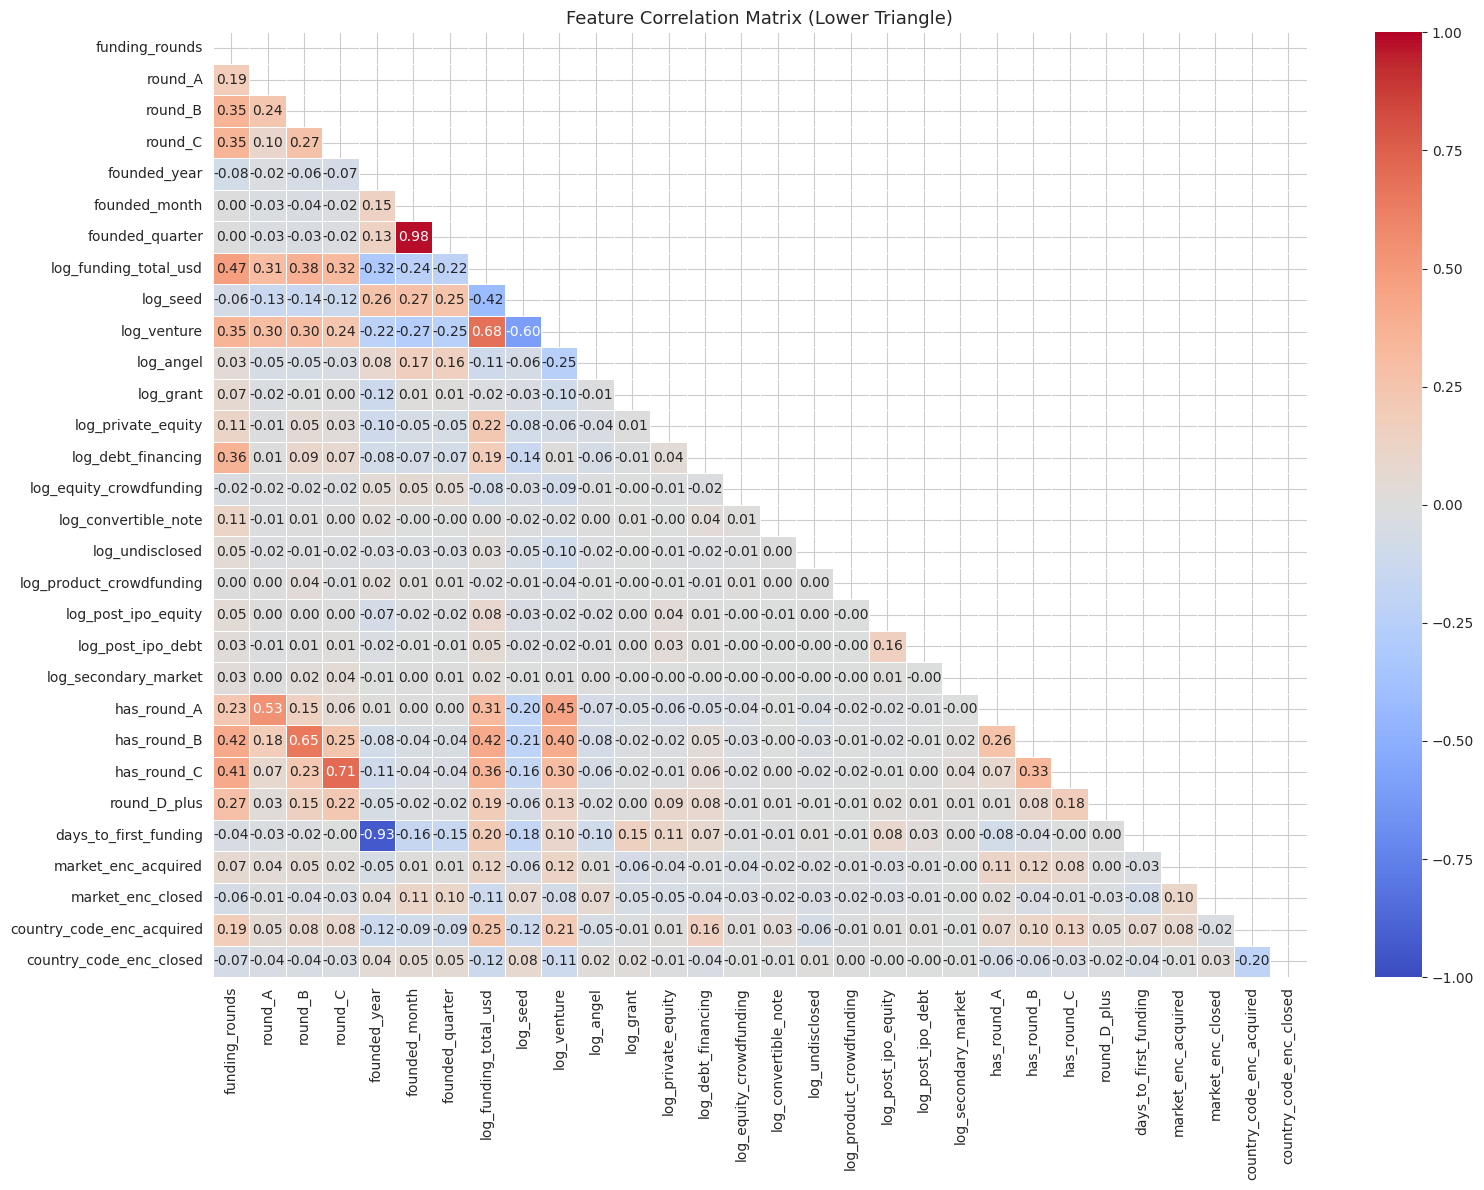

In [8]:
correlation_matrix = X_train.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
CORRELATION_THRESHOLD = 0.7

corr_abs  = correlation_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# For each correlated pair, drop the one with the lower ANOVA F-value
f_value_map = dict(zip(anova_df['Feature'], anova_df['F-Value']))

to_drop_corr = set()
for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > CORRELATION_THRESHOLD:
            # Keep the feature with the higher F-value, drop the other
            if f_value_map.get(row, 0) >= f_value_map.get(col, 0):
                to_drop_corr.add(col)
            else:
                to_drop_corr.add(row)

#ALWAYS_KEEP = ['days_to_first_funding']  # add any features you want protected here
#to_drop_corr = [f for f in to_drop_corr if f not in ALWAYS_KEEP]

to_drop_corr = list(to_drop_corr)
print(f"Correlation threshold : {CORRELATION_THRESHOLD}")
print(f"Original features     : {X_train.shape[1]}")
print(f"Features to drop      : {to_drop_corr}")
print(f"Remaining features    : {X_train.shape[1] - len(to_drop_corr)}")



Correlation threshold : 0.7
Original features     : 30
Features to drop      : ['round_C', 'founded_quarter', 'days_to_first_funding']
Remaining features    : 27


> **→ Modeling Decision:** Features with pairwise correlation > 0.7 are candidates for removal. We note which features are collinear and consider dropping the one with the lower ANOVA F-value in the final selection.

## 5. Model-Based Feature Importance (Wrapper Methods)

Wrapper methods evaluate feature importance **through model training**. Each method uses a different mechanism:

| Method | Mechanism |
|--------|-----------|
| **Random Forest** | Mean impurity decrease (Gini) across trees |
| **Gradient Boosting** | Feature usage frequency × gain in all trees |
| **Lasso (L1)** | Shrinks less-useful coefficients to exactly zero |
| **Ridge (L2)** | Shrinks coefficients toward zero — retains all features |
| **Linear SVM (L1)** | Sparse weight vector via L1 penalty |

In [10]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_selected = (rf.feature_importances_ > 0).astype(int)
print(f"Random Forest — features with importance > 0: {rf_selected.sum()}")

Random Forest — features with importance > 0: 30


In [11]:
# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
gb_selected = (gb.feature_importances_ > 0).astype(int)
print(f"Gradient Boosting — features with importance > 0: {gb_selected.sum()}")

Gradient Boosting — features with importance > 0: 29


In [12]:
# --- Lasso (L1) ---
# Lasso performs feature selection by zeroing out less-relevant coefficients.
# Higher alpha = stronger penalty = more features zeroed out.
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
lasso.fit(X_train, y_train)
# For multiclass: a feature is selected if any class has a non-zero coefficient
lasso_selected = (np.abs(lasso.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Lasso (L1 Logistic) — features selected: {lasso_selected.sum()}")

Lasso (L1 Logistic) — features selected: 0


In [13]:
# --- Ridge (L2) ---
# Ridge shrinks coefficients toward zero but rarely sets them exactly to zero.
# Useful for identifying relatively less informative features (very low coefs).
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0,
                            random_state=RANDOM_STATE, max_iter=2000,
                            multi_class='ovr')
ridge.fit(X_train, y_train)
# Select features whose total absolute coefficient across classes is above median
ridge_coef_sum = np.abs(ridge.coef_).sum(axis=0)
ridge_selected = (ridge_coef_sum > np.median(ridge_coef_sum)).astype(int)
print(f"Ridge (L2 Logistic) — features above median coef magnitude: {ridge_selected.sum()}")

Ridge (L2 Logistic) — features above median coef magnitude: 15


In [14]:
# --- Linear SVM with L1 penalty ---
# LinearSVC with L1 penalty produces sparse weight vectors (feature selection).
svm = LinearSVC(C=0.1, penalty='l1', dual=False, random_state=RANDOM_STATE, max_iter=3000)
svm.fit(X_train, y_train)
svm_selected = (np.abs(svm.coef_).sum(axis=0) > 1e-6).astype(int)
print(f"Linear SVM (L1) — features selected: {svm_selected.sum()}")

Linear SVM (L1) — features selected: 26


## 6. Forward Sequential Feature Selection

Forward selection greedily adds the feature that most improves cross-validated performance at each step.  
It captures **feature interactions** that filter methods miss.

In [ ]:
sfs_estimator = RandomForestClassifier(
    n_estimators=30,        # was 100 — enough for selection, not final modeling
    max_depth=8,            # cap depth to speed up each fit
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sfs = SequentialFeatureSelector(
    sfs_estimator,
    n_features_to_select=10,   # was 'auto' — set a fixed cap instead of open-ended
    direction='forward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)
sfs.fit(X_train, y_train)

forward_selected = sfs.get_support().astype(int)
forward_features = X_train.columns[sfs.get_support()].tolist()
print(f"Forward Selection — features selected ({len(forward_features)}): {forward_features}")

## 7. Permutation Importance

Permutation Importance measures how much the model's performance **drops** when a single feature's values are randomly shuffled.  
- A large drop → the model relied heavily on that feature.
- Advantage over built-in importance: works for any fitted model and captures the actual prediction impact.

In [ ]:
perm = permutation_importance(
    rf, X_val, y_val,
    n_repeats=15,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pfi_df = pd.DataFrame({
    'Feature':          X_train.columns,
    'PFI Mean':         perm.importances_mean,
    'PFI Std':          perm.importances_std,
}).sort_values('PFI Mean', ascending=False).reset_index(drop=True)

pfi_selected = (perm.importances_mean > 0).astype(int)

print("Permutation Feature Importance (validation set, Macro F1 drop):")
display(pfi_df.round(5))

In [ ]:
pfi_sorted = pfi_df.sort_values('PFI Mean', ascending=True)
bar_colors = ['#4CAF50' if v > 0 else '#FF5722' for v in pfi_sorted['PFI Mean']]

plt.figure(figsize=(10, 6))
plt.barh(pfi_sorted['Feature'], pfi_sorted['PFI Mean'],
         xerr=pfi_sorted['PFI Std'], color=bar_colors, edgecolor='white', capsize=4)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Permutation Feature Importance (Random Forest, Validation Set)', fontsize=12)
plt.xlabel('Mean Macro F1 Drop when Feature Shuffled')
plt.tight_layout()
plt.show()

## 8. Feature Selection Voting — Aggregated Results

We combine all selection signals into a single vote table.  
Features consistently selected across multiple methods are the most reliable.

In [ ]:
selection_df = pd.DataFrame({
    'Feature':       X_train.columns,
    'ANOVA':         anova_selected,
    'Lasso':         lasso_selected,
    'SVM':           svm_selected,
    'GradientBoost': gb_selected,
    'RandomForest':  rf_selected,
    'Ridge':         ridge_selected,
    'Forward':       forward_selected,
    #'PFI':           pfi_selected,
})

vote_cols = ['ANOVA', 'Lasso', 'SVM', 'GradientBoost', 'RandomForest', 'Ridge', 'Forward']
selection_df['Sum'] = selection_df[vote_cols].sum(axis=1)
selection_df = selection_df.sort_values('Sum', ascending=False).reset_index(drop=True)

display(selection_df)

In [ ]:
# Heatmap of selection votes
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(X_train.columns) * 0.5)))

# Heatmap
heatmap_data = selection_df.set_index('Feature')[vote_cols]
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, ax=axes[0], cbar=False,
            vmin=0, vmax=1)
axes[0].set_title('Feature Selection Votes per Method\n(1 = selected, 0 = not selected)')
axes[0].set_xlabel('')

# Bar chart of total votes
sorted_sel = selection_df.sort_values('Sum', ascending=True)
bar_c = ['#4CAF50' if s >= 5 else '#FF9800' if s >= 3 else '#FF5722'
         for s in sorted_sel['Sum']]
axes[1].barh(sorted_sel['Feature'], sorted_sel['Sum'], color=bar_c, edgecolor='white')
axes[1].axvline(5, color='green',  linestyle='--', label='≥5 votes (strong)', alpha=0.7)
axes[1].axvline(3, color='orange', linestyle='--', label='≥3 votes (moderate)', alpha=0.7)
axes[1].set_title('Total Selection Votes Across All Methods')
axes[1].set_xlabel('Number of Methods That Selected Feature')
axes[1].set_xlim(0, len(vote_cols) + 0.5)
axes[1].legend(fontsize=9)
for i, v in enumerate(sorted_sel['Sum']):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Feature Selection — Multi-Method Vote Summary', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Select features recommended by >= VOTE_THRESHOLD methods
VOTE_THRESHOLD = 5

selected_features = selection_df[selection_df['Sum'] >= VOTE_THRESHOLD]['Feature'].tolist()
all_features      = X_train.columns.tolist()

print(f"Vote threshold: {VOTE_THRESHOLD} / {len(vote_cols)} methods")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Dropped features  ({len(all_features) - len(selected_features)}): "
      f"{[f for f in all_features if f not in selected_features]}")

# Build filtered datasets
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

> **→ Modeling Decision:** Features selected by ≥ 5 of 8 methods form our **selected feature set**. We will compare models trained on the **full feature set** vs the **selected feature set** to confirm the selection improves or maintains performance.

---
# Part B — Modeling with Regularization

We train five model families on **each of the four resampling datasets** produced by `04_Imbalanced_Data.ipynb`:

| File | Technique |
|------|-----------|
| `train_resampled_ros.csv` | Random Over-Sampling |
| `train_resampled_rus.csv` | Random Under-Sampling |
| `train_resampled_smote.csv` | SMOTE |
| `train_resampled_smotetomek.csv` | SMOTETomek |

For every combination we record **Accuracy, Macro F1, Weighted F1, Precision, Recall, and per-class F1/Precision/Recall** on the validation set.
The baseline (no resampling) is excluded from model training but included as a reference line in the comparison charts.

All models use the **selected feature set** from Part A.

## 9. Define Models & Resampling Files

In [ ]:
RESAMPLE_FILES = {
    'ROS':        'data/train_resampled_ros.csv',
    'RUS':        'data/train_resampled_rus.csv',
    'SMOTE':      'data/train_resampled_smote.csv',
    'SMOTETomek': 'data/train_resampled_smotetomek.csv',
}

models = {
    'LR (L2)': LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        multi_class='multinomial', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'LR (L1)': LogisticRegression(
        penalty='l1', C=0.5, solver='saga',
        multi_class='ovr', max_iter=2000,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12,
        max_features='sqrt', min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='mlogloss', verbosity=0,
        random_state=RANDOM_STATE
    ),
}

print(f"Resampling strategies : {list(RESAMPLE_FILES.keys())}")
print(f"Models                : {list(models.keys())}")
print(f"Total runs            : {len(RESAMPLE_FILES) * len(models)} (+ feature set on selected)")

## 10. Extended Metrics Helper

We expand the metrics dict from Part A to include **per-class Precision and Recall** alongside F1,
giving a complete picture of where each model is trading off false positives vs false negatives.

In [ ]:
def full_metrics(y_true, y_pred, model_name='', resample=''):
    """Comprehensive metrics dict — overall + per-class P / R / F1."""
    f1_per   = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    prec_per = precision_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    rec_per  = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    return {
        'Model':               model_name,
        'Resample':            resample,
        # ── Overall ──────────────────────────────────────────────────────
        'Accuracy':            accuracy_score(y_true, y_pred),
        'Macro F1':            f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'Macro Precision':     precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'Macro Recall':        recall_score(y_true, y_pred, average='macro',       zero_division=0),
        'Weighted F1':         f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Weighted Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Weighted Recall':     recall_score(y_true, y_pred, average='weighted',    zero_division=0),
        # ── Per class ────────────────────────────────────────────────────
        'F1 closed':           f1_per[0],
        'Prec closed':         prec_per[0],
        'Rec closed':          rec_per[0],
        'F1 operating':        f1_per[1],
        'Prec operating':      prec_per[1],
        'Rec operating':       rec_per[1],
        'F1 acquired':         f1_per[2],
        'Prec acquired':       prec_per[2],
        'Rec acquired':        rec_per[2],
    }

print("full_metrics() defined — columns:",
      [k for k in full_metrics([0],[0]).keys()])

## 11. Train All Models × All Resampling Strategies

Each model is trained on the **selected feature set** from Part A.  
Val and test sets are never used during training or selection.

In [ ]:
import copy

all_results  = []   # list of metrics dicts
fitted_store = {}   # key: (resample_name, model_name) → fitted model

for resample_name, filepath in RESAMPLE_FILES.items():
    train_r = pd.read_csv(filepath)
    X_tr = prepare_X(train_r)          # drop raw funding + geo_cluster
    X_tr = X_tr[selected_features]     # selected feature set from Part A
    y_tr = train_r['status_code']

    print(f"\n{'─'*60}")
    print(f" {resample_name}  —  train shape: {X_tr.shape}")
    print(f"{'─'*60}")

    for model_name, model in models.items():
        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_val_sel)

        metrics = full_metrics(y_val, y_pred,
                               model_name=model_name,
                               resample=resample_name)
        all_results.append(metrics)
        fitted_store[(resample_name, model_name)] = m

        print(f"  {model_name:20s}  "
              f"Acc={metrics['Accuracy']:.4f}  "
              f"Macro F1={metrics['Macro F1']:.4f}  "
              f"Prec={metrics['Macro Precision']:.4f}  "
              f"Rec={metrics['Macro Recall']:.4f}")

results_df = pd.DataFrame(all_results)
print(f"\nTotal runs: {len(results_df)}")

## 12. Results Summary Table

Sorted by **Macro F1** — our primary selection criterion.  
The table shows all overall metrics; per-class breakdown follows in Section 13.

In [ ]:
summary_cols = ['Model', 'Resample', 'Accuracy',
                'Macro F1', 'Macro Precision', 'Macro Recall',
                'Weighted F1', 'Weighted Precision', 'Weighted Recall']

summary_df = results_df[summary_cols].sort_values('Macro F1', ascending=False).reset_index(drop=True)
display(summary_df.round(4))

## 13. Per-Class Metrics Breakdown

Precision, Recall, and F1 for each class — sorted by Macro F1.  
**Key tradeoff to watch:** high Recall on *closed* / *acquired* vs acceptable Precision.  
A model that improves minority recall but tanks precision is just predicting those classes more recklessly.

In [ ]:
per_class_cols = ['Model', 'Resample', 'Accuracy',
                  'Prec closed',   'Rec closed',   'F1 closed',
                  'Prec operating','Rec operating','F1 operating',
                  'Prec acquired', 'Rec acquired', 'F1 acquired']

per_class_df = results_df[per_class_cols].sort_values(
    ['F1 closed', 'F1 acquired'], ascending=False
).reset_index(drop=True)

display(per_class_df.round(4))

## 14. Visual Comparison

### 14.1 Macro Metrics by Model × Resampling Strategy

In [ ]:
macro_metrics = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
resample_colors = {'ROS': '#2196F3', 'RUS': '#FF5722',
                   'SMOTE': '#4CAF50', 'SMOTETomek': '#9C27B0'}
model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.2

fig, axes = plt.subplots(1, 4, figsize=(26, 6))

for ax, metric in zip(axes, macro_metrics):
    for i, (resample, color) in enumerate(resample_colors.items()):
        vals = [results_df[(results_df['Model'] == m) &
                           (results_df['Resample'] == resample)][metric].values[0]
                for m in model_names]
        bars = ax.bar(x + i * width, vals, width, label=resample,
                      color=color, edgecolor='white', alpha=0.9)
    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Macro Metrics — All Models × Resampling Strategies (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

### 14.2 Per-Class F1 Heatmap — All Combinations

In [ ]:
# Build a combined label for each run
results_df['Run'] = results_df['Resample'] + ' | ' + results_df['Model']

heatmap_data = results_df.set_index('Run')[['Accuracy',
                                              'F1 closed', 'F1 operating', 'F1 acquired',
                                              'Rec closed', 'Rec acquired']]\
                          .sort_values('F1 closed', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(heatmap_data) * 0.45)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Score'})
ax.set_title('Per-Class F1 + Minority Recall — All Runs\n(sorted by F1 closed)', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 14.3 Precision vs Recall Trade-off — Minority Classes

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (cls, prec_col, rec_col) in zip(axes, [
    ('closed',   'Prec closed',   'Rec closed'),
    ('acquired', 'Prec acquired', 'Rec acquired'),
]):
    for resample, color in resample_colors.items():
        sub = results_df[results_df['Resample'] == resample]
        ax.scatter(sub[rec_col], sub[prec_col],
                   c=color, label=resample, s=100, edgecolors='white', linewidth=0.5, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(row['Model'][:4],  # first 4 chars to keep labels short
                        (row[rec_col], row[prec_col]),
                        fontsize=7, ha='left', va='bottom')
    ax.set_xlabel(f'Recall ({cls})', fontsize=11)
    ax.set_ylabel(f'Precision ({cls})', fontsize=11)
    ax.set_title(f'Precision vs Recall — {cls}', fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='grey', linestyle='--', alpha=0.4)
    ax.axvline(0.5, color='grey', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Precision–Recall Trade-off — Minority Classes (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Regularization Sensitivity — Best Model

We identify the best (model, resampling) combination from Section 12 first, then sweep
its key regularization parameters to find the optimal setting before final evaluation.

- **Random Forest** → `max_depth` × `min_samples_leaf`
- **XGBoost / Gradient Boosting** → `reg_alpha` (L1) × `reg_lambda` (L2)
- **Logistic Regression** → `C` (inverse regularization strength)

The sweep always uses the resampling strategy that gave the best result for that model.

In [ ]:
import copy

# ── Identify best combination first (reused by Sections 16–20) ───────────
best_row      = results_df.loc[results_df['Macro F1'].idxmax()]
best_resample = best_row['Resample']
best_model    = best_row['Model']
best_fitted   = fitted_store[(best_resample, best_model)]

print(f"Best combination: {best_model} + {best_resample}  "
      f"(Macro F1 = {best_row['Macro F1']:.4f})")
print(f"Running regularization sweep for: {best_model}\n")

# ── Load best resampling training set ────────────────────────────────────
train_best = pd.read_csv(RESAMPLE_FILES[best_resample])
X_tr_best  = prepare_X(train_best)[selected_features]
y_tr_best  = train_best['status_code']

reg_results = []

# ── Random Forest sweep ───────────────────────────────────────────────────
if best_model == 'Random Forest':
    max_depths        = [4, 6, 8, 10, 12, None]
    min_samples_leafs = [1, 2, 3, 5, 10]
    for md_val in max_depths:
        for msl in min_samples_leafs:
            m = RandomForestClassifier(
                n_estimators=300, max_features='sqrt',
                class_weight='balanced',
                max_depth=md_val, min_samples_leaf=msl,
                random_state=RANDOM_STATE, n_jobs=-1
            )
            m.fit(X_tr_best, y_tr_best)
            y_pred = m.predict(X_val_sel)
            reg_results.append({
                'max_depth':        str(md_val) if md_val is not None else 'None',
                'min_samples_leaf': msl,
                'Macro F1':         f1_score(y_val, y_pred, average='macro', zero_division=0),
                'Rec closed':       recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
                'Rec acquired':     recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
            })
    reg_df = pd.DataFrame(reg_results)
    row_key, col_key = 'max_depth', 'min_samples_leaf'

# ── XGBoost / Gradient Boosting sweep ────────────────────────────────────
elif best_model in ('XGBoost', 'Gradient Boosting'):
    alphas  = [0, 0.01, 0.1, 0.5, 1.0, 2.0]
    lambdas = [0.1, 0.5, 1.0, 2.0, 5.0]
    for alpha in alphas:
        for lam in lambdas:
            if best_model == 'XGBoost':
                m = XGBClassifier(
                    n_estimators=200, max_depth=5, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    reg_alpha=alpha, reg_lambda=lam,
                    eval_metric='mlogloss', verbosity=0, random_state=RANDOM_STATE
                )
            else:
                m = GradientBoostingClassifier(
                    n_estimators=200, max_depth=5, learning_rate=0.05,
                    subsample=0.8, random_state=RANDOM_STATE
                )
            m.fit(X_tr_best, y_tr_best)
            y_pred = m.predict(X_val_sel)
            reg_results.append({
                'reg_alpha':    alpha,
                'reg_lambda':   lam,
                'Macro F1':     f1_score(y_val, y_pred, average='macro', zero_division=0),
                'Rec closed':   recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
                'Rec acquired': recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
            })
    reg_df = pd.DataFrame(reg_results)
    row_key, col_key = 'reg_alpha', 'reg_lambda'

# ── Logistic Regression sweep ─────────────────────────────────────────────
elif 'LR' in best_model:
    C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
    penalty  = 'l1' if 'L1' in best_model else 'l2'
    solver   = 'saga' if penalty == 'l1' else 'lbfgs'
    for C in C_values:
        m = LogisticRegression(
            penalty=penalty, C=C, solver=solver,
            multi_class='ovr', max_iter=2000, random_state=RANDOM_STATE
        )
        m.fit(X_tr_best, y_tr_best)
        y_pred = m.predict(X_val_sel)
        reg_results.append({
            'C':            C,
            'Macro F1':     f1_score(y_val, y_pred, average='macro', zero_division=0),
            'Rec closed':   recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[0],
            'Rec acquired': recall_score(y_val, y_pred, average=None, labels=[0,1,2], zero_division=0)[2],
        })
    reg_df = pd.DataFrame(reg_results).set_index('C')
    reg_df.plot(kind='bar', figsize=(12, 5), color=['#2196F3','#FF5722','#4CAF50'], edgecolor='white')
    plt.title(f'Regularization Sweep — {best_model} ({best_resample})', fontsize=12)
    plt.xlabel('C (inverse regularization)')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.legend()
    plt.tight_layout()
    plt.show()
    best_reg = reg_df['Macro F1'].idxmax()
    print(f"Best C = {best_reg}  →  Macro F1 = {reg_df.loc[best_reg, 'Macro F1']:.4f}")
    reg_df = None  # skip heatmap block below

# ── Heatmap (RF / XGBoost / GB only) ─────────────────────────────────────
if reg_df is not None and row_key in reg_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, title in zip(axes,
        ['Macro F1', 'Rec closed', 'Rec acquired'],
        ['Macro F1', 'Recall — closed', 'Recall — acquired']):
        pivot = reg_df.pivot(index=row_key, columns=col_key, values=metric)
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', linewidths=0.5,
                    ax=ax, cbar_kws={'label': metric})
        ax.set_title(f'{best_model} — {title}', fontsize=11)
        ax.set_xlabel(col_key)
        ax.set_ylabel(row_key)
    plt.suptitle(f'Regularization Sweep — {best_model} on {best_resample} (Validation Set)', fontsize=12)
    plt.tight_layout()
    plt.show()

    best_reg = reg_df.loc[reg_df['Macro F1'].idxmax()]
    print(f"Best: {row_key}={best_reg[row_key]}, {col_key}={best_reg[col_key]}  "
          f"→  Macro F1={best_reg['Macro F1']:.4f}")

## 16. Final Model Selection

We select the single best (model, resampling) combination by **Macro F1**, then confirm it
is also competitive on minority-class Recall before proceeding to test-set evaluation.

In [ ]:
# best_row, best_resample, best_model, best_fitted are set in Section 15
print("Best combination (by Macro F1 on validation set):")
print(f"  Model      : {best_model}")
print(f"  Resampling : {best_resample}")
print(f"  Accuracy   : {best_row['Accuracy']:.4f}")
print(f"  Macro F1   : {best_row['Macro F1']:.4f}")
print(f"  Macro Prec : {best_row['Macro Precision']:.4f}")
print(f"  Macro Rec  : {best_row['Macro Recall']:.4f}")
print(f"  Rec closed : {best_row['Rec closed']:.4f}")
print(f"  Rec acquired: {best_row['Rec acquired']:.4f}")

# Show top-5 for transparency
print("\nTop-5 runs:")
display(results_df[['Model','Resample','Accuracy','Macro F1','Macro Precision','Macro Recall',
                     'Rec closed','Rec acquired']]
        .sort_values('Macro F1', ascending=False).head(5).round(4))

In [ ]:
# Top-3 runs — confusion matrices side by side
top3_rows = results_df.sort_values('Macro F1', ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_, row) in zip(axes, top3_rows.iterrows()):
    key     = (row['Resample'], row['Model'])
    fitted  = fitted_store[key]
    y_pred  = fitted.predict(X_val_sel)
    acc     = row['Accuracy']
    f1      = row['Macro F1']
    rec_c   = row['Rec closed']
    rec_a   = row['Rec acquired']
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    ax.set_title(f"{row['Resample']} | {row['Model']}\n"
                 f"Acc={acc:.3f}  Macro F1={f1:.3f}  "
                 f"Rec↑closed={rec_c:.3f}  Rec↑acq={rec_a:.3f}",
                 fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Top-3 Combinations — Confusion Matrices (Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 17. ROC Curves — Best Model (Validation Set)

One-vs-rest ROC per class, comparing all four resampling strategies for the best model type.

In [ ]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls_idx, cls_name in enumerate(STATUS_NAMES):
    ax = axes[cls_idx]
    for resample, color in resample_colors.items():
        key = (resample, best_model)
        if key not in fitted_store:
            continue
        fitted = fitted_store[key]
        try:
            proba = fitted.predict_proba(X_val_sel)[:, cls_idx]
            fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{resample} (AUC={roc_auc:.2f})',
                    color=color, linewidth=1.8)
        except AttributeError:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC — {cls_name} (one-vs-rest)\nModel: {best_model}', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'ROC Curves — {best_model} across Resampling Strategies (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

## 18. Full Validation Report — Best Combination

In [ ]:
y_pred_best_val = best_fitted.predict(X_val_sel)

print(f"Best model : {best_model}")
print(f"Resampling : {best_resample}")
print(f"Features   : {len(selected_features)} selected features")
print(f"Accuracy   : {accuracy_score(y_val, y_pred_best_val):.4f}")
print()
print(classification_report(y_val, y_pred_best_val,
                             target_names=STATUS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_val, y_pred_best_val, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
ax.set_title(f'{best_model} ({best_resample}) — Validation Set\n'
             f'Macro F1 = {best_row["Macro F1"]:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 19. Final Evaluation on Test Set

> ⚠️ **Run this cell only once.** The test set has not been touched during any selection step.
> Using it iteratively would invalidate the result.

In [ ]:
y_pred_test = best_fitted.predict(X_test_sel)

print("="*60)
print(f" FINAL TEST SET — {best_model}  [{best_resample}]")
print("="*60)
print(f" Accuracy (val)  : {accuracy_score(y_val,  y_pred_best_val):.4f}")
print(f" Accuracy (test) : {accuracy_score(y_test, y_pred_test):.4f}")
print()
print(classification_report(y_test, y_pred_test,
                             target_names=STATUS_NAMES, zero_division=0))

# Val vs Test side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, split in zip(axes,
                              [y_pred_best_val, y_pred_test],
                              ['Validation', 'Test']):
    y_true = y_val if split == 'Validation' else y_test
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    ax.set_title(f'{split} Set — Acc={acc:.4f}  Macro F1={f1:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(f'Best Model: {best_model} ({best_resample})', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Val vs Test — per-class P / R / F1 comparison
metrics_compare = {}
for split, y_true, y_pred in [
    ('Validation', y_val,  y_pred_best_val),
    ('Test',       y_test, y_pred_test)
]:
    f1_per   = f1_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    prec_per = precision_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    rec_per  = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
    metrics_compare[split] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        **{f'F1 {c}':   v for c, v in zip(STATUS_NAMES, f1_per)},
        **{f'Prec {c}': v for c, v in zip(STATUS_NAMES, prec_per)},
        **{f'Rec {c}':  v for c, v in zip(STATUS_NAMES, rec_per)},
    }

compare_df = pd.DataFrame(metrics_compare).T
display(compare_df.round(4))

# Bar chart
plot_cols = [f'{m} {c}' for c in STATUS_NAMES for m in ['F1','Prec','Rec']]
compare_df[plot_cols].T.plot(kind='bar', figsize=(16, 5),
                              color=['#2196F3','#FF9800'], edgecolor='white')
plt.title('Per-Class F1 / Precision / Recall — Validation vs Test Set')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

## 20. Feature Importance — Best Model

In [ ]:
if hasattr(best_fitted, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    selected_features,
        'Importance': best_fitted.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, max(5, len(selected_features) * 0.4)))
    bars = plt.barh(imp_df['Feature'], imp_df['Importance'],
                    color='#2196F3', edgecolor='white')
    for bar, v in zip(bars, imp_df['Importance']):
        plt.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=8)
    plt.title(f'Feature Importances — {best_model} ({best_resample})', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

elif hasattr(best_fitted, 'coef_'):
    coef_mat = np.abs(best_fitted.coef_)
    imp_df = pd.DataFrame(coef_mat.T, index=selected_features, columns=STATUS_NAMES)
    imp_df['Mean |coef|'] = imp_df.mean(axis=1)
    imp_df = imp_df.sort_values('Mean |coef|', ascending=True)
    imp_df[STATUS_NAMES].plot(kind='barh', figsize=(12, max(5, len(selected_features) * 0.4)),
                              color=COLORS, edgecolor='white')
    plt.title(f'Coefficient Magnitudes — {best_model} ({best_resample})', fontsize=12)
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## Summary

### Feature Selection (Part A)
| Step | Method | Outcome |
|------|--------|---------|
| Filter | ANOVA F-test + Chi-squared | Statistical ranking of features |
| Correlation | Pearson matrix | Identified collinear pairs |
| Wrapper (importance) | RF, GB, Lasso, Ridge, SVM | Binary vote per method |
| Wrapper (sequential) | Forward Selection | Interaction-aware vote |
| Post-hoc | Permutation Importance | Val-set impact confirmation |
| **Aggregated** | **Vote ≥ 5 / 8** | **Final selected feature set** |

### Modeling (Part B)
| Step | Detail |
|------|--------|
| Resampling strategies | ROS, RUS, SMOTE, SMOTETomek |
| Models | LR (L1/L2), Random Forest, Gradient Boosting, XGBoost |
| Total runs | 4 strategies × 5 models = 20 combinations |
| Metrics tracked | Accuracy, Macro/Weighted F1 + Precision + Recall, per-class P/R/F1 |
| Regularization sweep | XGBoost reg_alpha × reg_lambda on best resampling |
| Selection criterion | **Macro F1** on validation set |
| Test evaluation | Single one-shot run in Section 19 |

### Output Files
| File | Description |
|------|-------------|
| `data/train_resampled_ros.csv` | ROS training set |
| `data/train_resampled_rus.csv` | RUS training set |
| `data/train_resampled_smote.csv` | SMOTE training set |
| `data/train_resampled_smotetomek.csv` | SMOTETomek training set |
| `data/val_processed.csv` | Validation — unchanged throughout |
| `data/test_processed.csv` | Test — used only in Section 19 |